<a href="https://colab.research.google.com/github/RegiRezende/MathCode/blob/Python_codes/Turbulencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FFT em Turbulência

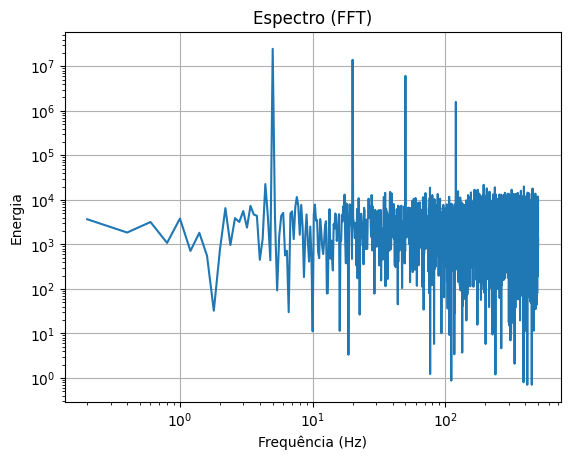

Faixa de frequências captadas:
f_min = 5.0 Hz
f_max = 120.0 Hz
Velocidade média: 9.999829557905338 m/s


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ====== 1. CARREGAR DADOS ======
x = np.loadtxt('dados_jato.txt')   # <-- coloque seu arquivo aqui

# ====== 2. DEFINIR AMOSTRAGEM ======
fs = 1000  # Hz (IMPORTANTE: ajuste para seu experimento!)
dt = 1/fs
N = len(x)

# ====== 3. REMOVER MÉDIA ======
U_mean = np.mean(x)   # antes de remover a média

x = x - np.mean(x)    # remove a média

# ====== 4. FFT ======
X = np.fft.fft(x)
freq = np.fft.fftfreq(N, d=dt)

# ====== 5. PEGAR PARTE POSITIVA ======
mask = freq > 0
freq = freq[mask]
X = X[mask]

# ====== 6. ESPECTRO ======
E = np.abs(X)**2

# ====== 7. PLOT ======
plt.figure()
plt.loglog(freq, E)
plt.xlabel('Frequência (Hz)')
plt.ylabel('Energia')
plt.title('Espectro (FFT)')
plt.grid()
plt.show()

# ====== 8. IDENTIFICAR FAIXA RELEVANTE ======
threshold = 0.01 * np.max(E)

indices = np.where(E > threshold)[0]
f_min = freq[indices].min()
f_max = freq[indices].max()

print("Faixa de frequências captadas:")
print("f_min =", f_min, "Hz")
print("f_max =", f_max, "Hz")
print("Velocidade média:", U_mean, "m/s")